In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

### Analyzing Annotation Files

In [2]:
def read_annotation_files(annotation_folder):
    data = []
    for filename in os.listdir(annotation_folder):
        if filename.endswith(".txt"):
            filepath = os.path.join(annotation_folder, filename)
            with open(filepath, 'r') as file:
                for line in file:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    bbox = list(map(float, parts[1:]))
                    data.append([filename, class_id] + bbox)
    return pd.DataFrame(data, columns=['filename', 'class_id', 'x_center', 'y_center', 'width', 'height'])

In [3]:
def read_class_labels(file_path):
    with open(file_path, 'r') as file:
        class_labels = file.read().strip().split('\n')
    return class_labels

In [4]:
# Folder containing annotation files
annotation_folder = '../logistics'
annotations = read_annotation_files(annotation_folder)

class_labels_file = '../logistics/_darknet.labels'
class_labels = read_class_labels(class_labels_file)
annotations['class_label'] = annotations['class_id'].apply(lambda x: class_labels[x])

# Save the dataframe for further analysis
annotations.to_csv('annotations.csv', index=False)

In [5]:
class_distribution = annotations['class_label'].value_counts()
print("Class Distribution:\n", class_distribution)

Class Distribution:
 class_label
wood pallet          9330
person               6368
cardboard box        4995
fire                 2793
helmet               2170
smoke                1495
car                  1379
safety vest          1260
traffic light        1193
forklift             1103
truck                 782
van                   765
road sign             720
traffic cone          506
qr code               369
license plate         359
freight container     318
barcode               283
ladder                277
gloves                256
Name: count, dtype: int64


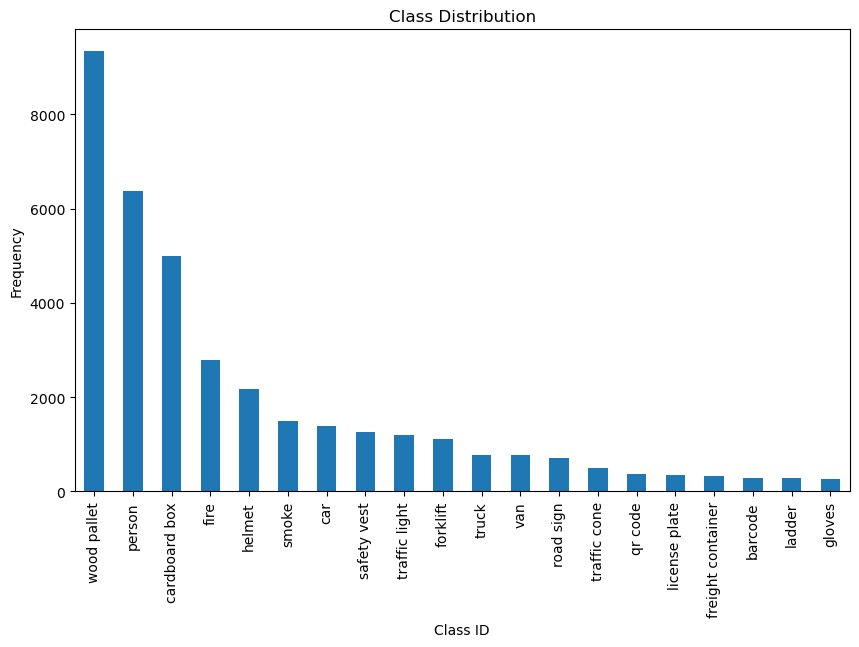

In [6]:
# Plot the distributions
plt.figure(figsize=(10, 6))
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class ID')
plt.ylabel('Frequency')
plt.savefig('class_distribution.png')
plt.show()

The class distribution in the dataset shows a significant imbalance among the various object classes. The most frequent classes are "wood pallet" (9330 instances) and "person" (6368 instances), while the least frequent classes are "gloves" (256 instances) and "ladder" (277 instances). Such imbalance can lead to a model that is biased towards detecting the more frequent classes, potentially missing or incorrectly classifying the less frequent ones. This imbalance shows the need to the use data augmentation techniques to artificially increase the number of instances of underrepresented classes. Additionally, careful selection and tuning of the model architecture and hyperparameters are required to mitigate the effects of class imbalance. Post-processing steps like Non-Maximum Suppression (NMS) and confidence thresholding need to be optimized to ensure reliable detections across all classes. Addressing these issues is critical for developing a robust object detection system that performs well on all classes, regardless of their frequency in the dataset.

In [7]:
annotations['bbox_area'] = annotations['width'] * annotations['height']
bbox_size_distribution = annotations['bbox_area'].describe()
print("Bounding Box Size Distribution:\n", bbox_size_distribution)

Bounding Box Size Distribution:
 count    36721.000000
mean         0.088726
std          0.170499
min          0.000005
25%          0.003711
50%          0.019453
75%          0.078625
max          1.000000
Name: bbox_area, dtype: float64


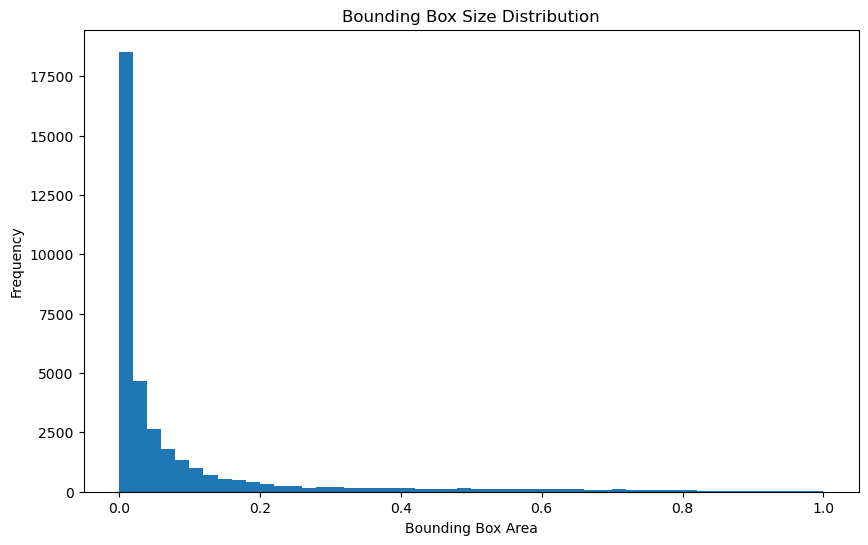

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(annotations['bbox_area'], bins=50)
plt.title('Bounding Box Size Distribution')
plt.xlabel('Bounding Box Area')
plt.ylabel('Frequency')
plt.savefig('bbox_size_distribution.png')
plt.show()

The bounding box size distribution in the dataset reveals significant variability in the sizes of the objects being detected. The mean bounding box area is approximately 0.0887, with a standard deviation of 0.1705, indicating a wide range of object sizes. The minimum bounding box area is almost negligible (0.000005), while the maximum is 1.0, suggesting that some objects span the entire image. The quartiles show that 25% of bounding boxes have an area less than 0.0037, 50% have an area less than 0.0195, and 75% have an area less than 0.0786. This distribution implies that the model must be capable of accurately detecting both very small and relatively large objects within the images. To address this, careful configuration of anchor boxes is essential, ensuring that they cover a diverse range of object sizes. Additionally, using multi-scale feature maps can help improve the model's ability to detect objects of varying sizes. These adjustments are crucial to enhance the detection accuracy and robustness of the object detection system.

In [9]:
def analyze_images(image_folder):
    image_stats = {
        "image_sizes": [],
        "aspect_ratios": [],
        "formats": [],
        "mean_brightness": []
    }

    for filename in os.listdir(image_folder):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            filepath = os.path.join(image_folder, filename)
            with Image.open(filepath) as img:
                image_stats["image_sizes"].append(img.size)
                aspect_ratio = img.size[0] / img.size[1]
                image_stats["aspect_ratios"].append(aspect_ratio)
                image_stats["formats"].append(img.format)
                brightness = np.array(img.convert("L")).mean()
                image_stats["mean_brightness"].append(brightness)

    return image_stats

In [10]:
# Folder containing training images
image_folder = '../logistics'
image_stats = analyze_images(image_folder)

# Save the results for further analysis
np.save('image_stats.npy', image_stats)

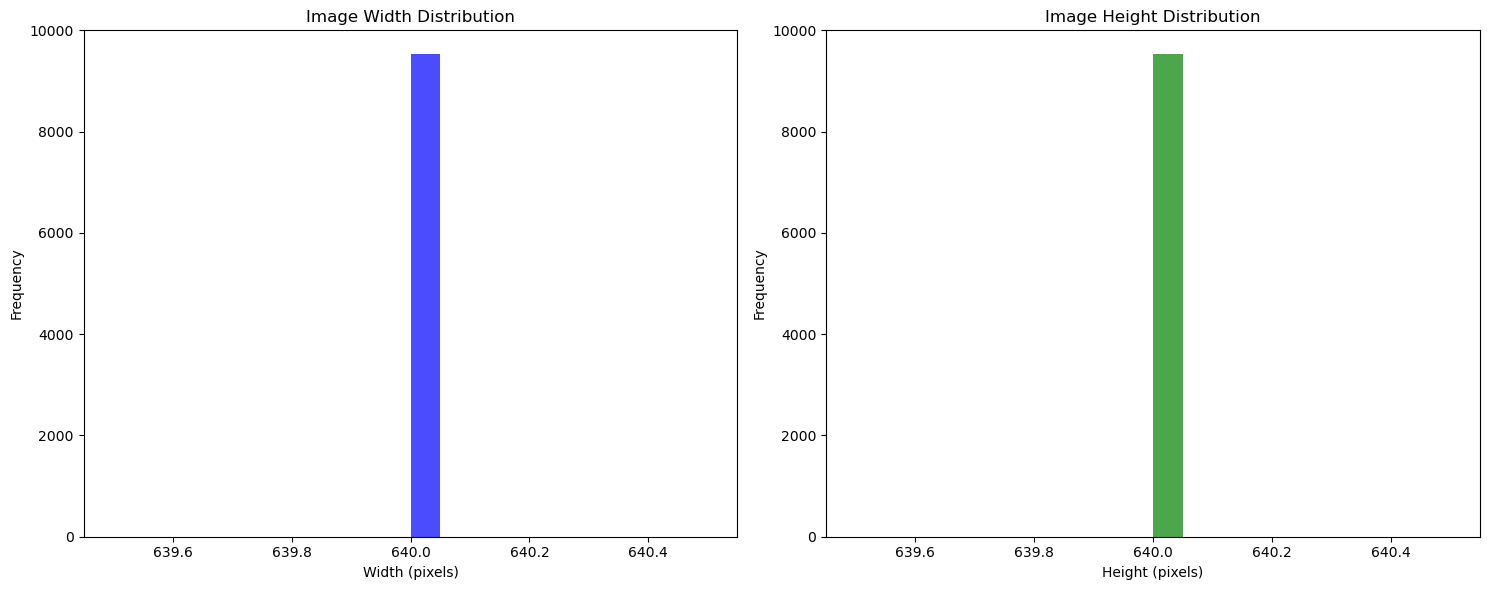

In [11]:
image_sizes = image_stats["image_sizes"]
widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

fig, axs = plt.subplots(1, 2, figsize=(15, 6))
axs[0].hist(widths, bins=20, alpha=0.7, color='blue')
axs[0].set_title('Image Width Distribution')
axs[0].set_xlabel('Width (pixels)')
axs[0].set_ylabel('Frequency')
axs[1].hist(heights, bins=20, alpha=0.7, color='green')
axs[1].set_title('Image Height Distribution')
axs[1].set_xlabel('Height (pixels)')
axs[1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('image_size_distribution_panels.png')
plt.show()

All images in the dataset are uniformly sized at 640x640 pixels. This consistency in image dimensions simplifies the preprocessing pipeline, as there is no need for additional resizing or aspect ratio adjustments before feeding the images into the model. Uniform image size ensures that the spatial features extracted by the convolutional layers remain consistent across the dataset, potentially leading to more stable training and better performance.

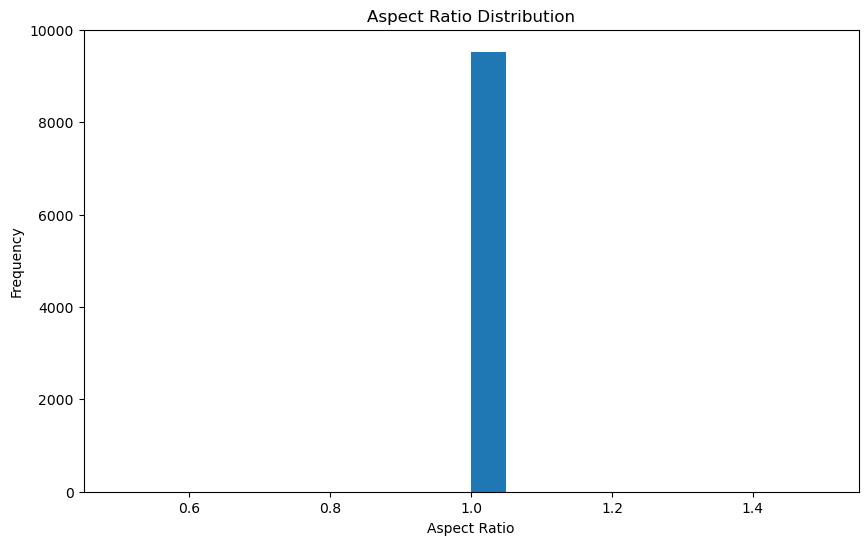

In [12]:
aspect_ratios = image_stats["aspect_ratios"]

plt.figure(figsize=(10, 6))
plt.hist(aspect_ratios, bins=20)
plt.title('Aspect Ratio Distribution')
plt.xlabel('Aspect Ratio')
plt.ylabel('Frequency')
plt.savefig('aspect_ratio_distribution.png')
plt.show()

All images in the dataset have a consistent aspect ratio of 1:1, meaning they are perfectly square. This uniformity in aspect ratio simplifies the design of the object detection model, as there is no need to account for variations in image shape that might otherwise complicate the detection process.

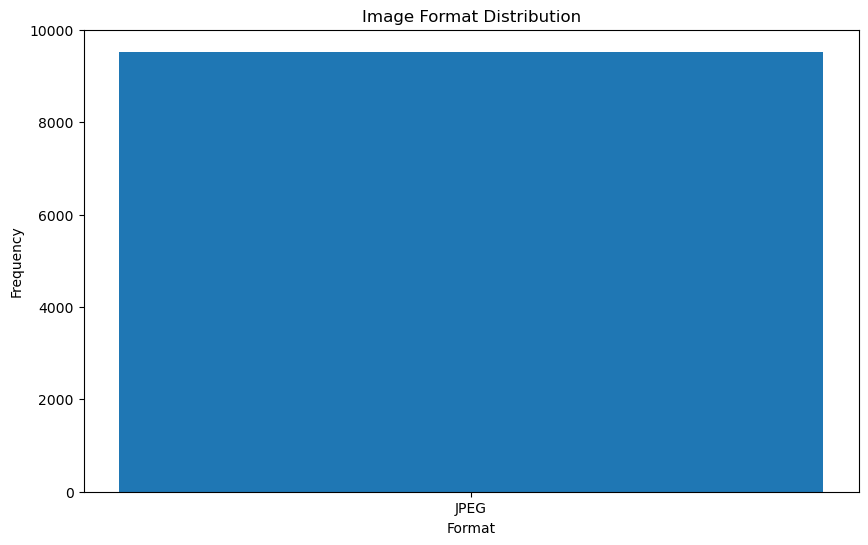

In [13]:
formats = image_stats["formats"]
format_counts = {fmt: formats.count(fmt) for fmt in set(formats)}

plt.figure(figsize=(10, 6))
plt.bar(format_counts.keys(), format_counts.values())
plt.title('Image Format Distribution')
plt.xlabel('Format')
plt.ylabel('Frequency')
plt.savefig('image_format_distribution.png')
plt.show()

All images in the dataset are in JPEG format, which is a widely used and efficient format for image compression. This consistency simplifies the preprocessing pipeline, as the model only needs to handle a single image format, reducing the potential for errors related to format conversion.

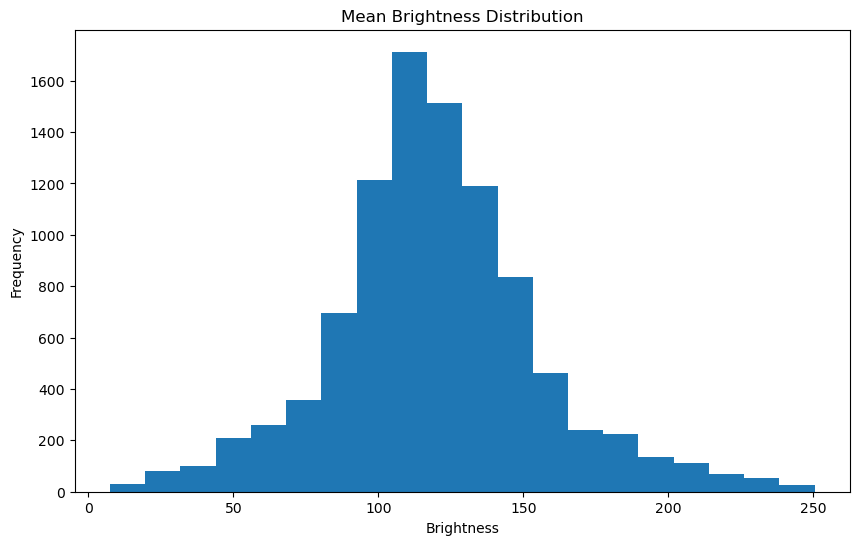

In [14]:
mean_brightness = image_stats["mean_brightness"]

plt.figure(figsize=(10, 6))
plt.hist(mean_brightness, bins=20)
plt.title('Mean Brightness Distribution')
plt.xlabel('Brightness')
plt.ylabel('Frequency')
plt.savefig('mean_brightness_distribution.png')
plt.show()

The images in the dataset appears to exhibit a normal distribution for mean brightness. This indicates that the lighting conditions are relatively consistent across the dataset, with most images having an average brightness level centered around a common mean. Such uniformity in brightness simplifies the model's task of learning relevant features, as it reduces the variability in pixel intensity caused by differing lighting conditions. However, it is still essential to ensure that the model can handle variations in lighting that might occur in real-world scenarios. To enhance the model's robustness to different lighting conditions, data augmentation techniques such as brightness and contrast adjustments should be applied during training.